In [16]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, validation_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import SurvivalToDischarge

In [2]:
X, y = SurvivalToDischarge.load_data(sample_size=100000, icu_vitals=True, top_n_labs=230, top_n_drugs=954, top_n_procedures=55)

Returing 100000 patient records with 660 columns. y distribution: 
hospital_expire_flag
0    0.97966
1    0.02034
Name: proportion, dtype: float64


In [3]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 660), Test: (20000, 660)


In [4]:
print(X.shape)
X.head(20)

(100000, 660)


,los_hours,anchor_age,gender_female,meanbp_systolic,meanbp_diastolic,maxbp_systolic,maxbp_diastolic,minbp_systolic,minbp_diastolic,result_value_x,...,admission_location_WALK-IN/SELF REFERRAL,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_BLACK,race_HISPANIC/LATINO,race_NATIVE AMERICAN/ALASKA NATIVE,race_UNKNOWN OR MULTIPLE,race_WHITE
0,135.316667,47,1,127.833333,73.250000,152.0,89.0,104.0,59.0,126.000000,...,1,0,0,0,1,0,0,0,0,1
1,92.466667,59,1,123.177778,74.888889,151.0,93.0,80.0,52.0,166.219512,...,0,0,0,0,1,1,0,0,0,0
2,89.916667,76,0,149.833333,59.500000,177.0,68.0,113.0,50.0,157.715000,...,0,1,0,0,0,0,0,0,0,1
3,5.266667,31,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,0,0,0,1,0,0,0
4,25.466667,74,1,145.500000,59.500000,176.0,80.0,122.0,36.0,148.657895,...,0,1,0,0,0,0,0,0,0,1
5,9.433333,47,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,1,0,0,1,0,0,0
6,15.533333,62,1,121.800000,69.200000,138.0,71.0,113.0,67.0,171.700000,...,0,0,0,0,1,0,0,0,0,1
7,78.033333,31,1,114.000000,70.750000,120.0,80.0,108.0,60.0,171.700000,...,0,0,0,0,1,1,0,0,0,0
8,60.633333,89,1,155.701754,68.719298,214.0,90.0,104.0,47.0,160.765455,...,0,1,0,0,0,0,0,0,0,1
9,62.233333,48,1,112.000000,78.200000,128.0,84.0,104.0,74.0,171.700000,...,0,0,0,0,1,0,0,0,1,0


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [6]:
param_range =  [3,5,7,10,15,20,30,50,100,500]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
mean_val = val_scores.mean(axis=1)
best_depth = param_range[np.argmax(mean_val)]
print("best max_depth:", best_depth)

best max_depth: 5


In [7]:
decision_tree_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18405     1188   (specificity 0.939)
  Actual 1          63      344   (sensitivity 0.845)

TPR (sensitivity):  0.845
FPR (fall-out):     0.061
Precision:          0.225
ROC-AUC:            0.903

              precision    recall  f1-score   support

    Survived       1.00      0.94      0.97     19593
        Died       0.22      0.85      0.35       407

    accuracy                           0.94     20000
   macro avg       0.61      0.89      0.66     20000
weighted avg       0.98      0.94      0.95     20000



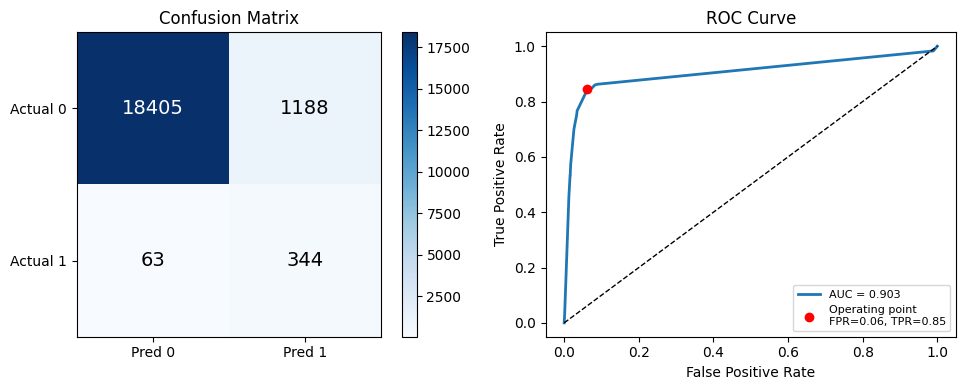

In [8]:
y_pred  = decision_tree_model.predict(X_test_scaled)
y_proba = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
decision_tree_max_depth = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19440      153   (specificity 0.992)
  Actual 1         147      260   (sensitivity 0.639)

TPR (sensitivity):  0.639
FPR (fall-out):     0.008
Precision:          0.630
ROC-AUC:            0.816

              precision    recall  f1-score   support

    Survived       0.99      0.99      0.99     19593
        Died       0.63      0.64      0.63       407

    accuracy                           0.98     20000
   macro avg       0.81      0.82      0.81     20000
weighted avg       0.99      0.98      0.99     20000



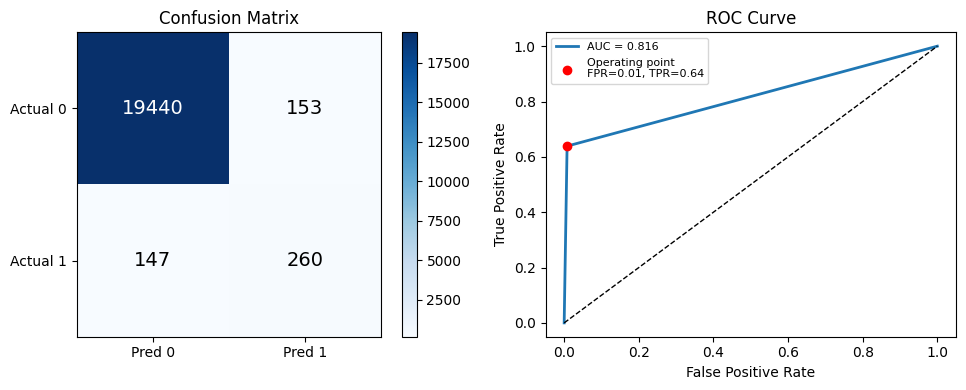

In [10]:
y_pred  = decision_tree_max_depth.predict(X_test_scaled)
y_proba = decision_tree_max_depth.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
random_forest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    verbose=2,
    n_jobs=-1).fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100building tree 11 of 100

building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.8s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.0s finished


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19087      506   (specificity 0.974)
  Actual 1          76      331   (sensitivity 0.813)

TPR (sensitivity):  0.813
FPR (fall-out):     0.026
Precision:          0.395
ROC-AUC:            0.982

              precision    recall  f1-score   support

    Survived       1.00      0.97      0.98     19593
        Died       0.40      0.81      0.53       407

    accuracy                           0.97     20000
   macro avg       0.70      0.89      0.76     20000
weighted avg       0.98      0.97      0.98     20000



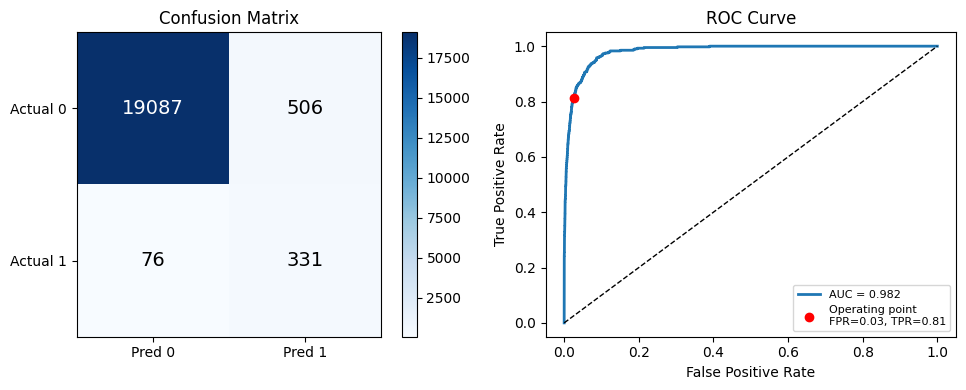

In [14]:
y_pred  = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
clf = RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=42)

param_dist = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [3, 5, 20, 30, None],
    "max_features": ["sqrt", 0.2, 0.5],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 50],
    "bootstrap": [True, False]
}

rs = RandomizedSearchCV(clf, param_dist, n_iter=100, cv=5, scoring="roc_auc", n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print(rs.best_params_)

c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
105 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
105 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\redja\App

{'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
